# 04 · EDA — 04. Variables numéricas, correlaciones y reducción dimensional

Cuarto notebook del análisis exploratorio. Se centra en el estudio de las **110 variables estadísticas
numéricas** del dataset (excluyendo identificadores, edad y target salarial).

## Bloques abordados

1. **Selección y caracterización** del subconjunto de variables numéricas (stats).
2. **Análisis de varianza**: detección de variables casi constantes (poca información).
3. **Matriz de correlación**: identificación de pares altamente correlacionados.
4. **Clustering jerárquico de variables**: agrupación en bloques temáticos.
5. **Análisis de Componentes Principales (PCA)**: estimación de la dimensión intrínseca del dataset.
6. **Conclusiones** orientadas a feature engineering y a los dos modelos previstos
   (regresión salarial + similitud entre jugadores).

⚠️ Este notebook tiene una doble función: identificar redundancias (clave para el modelo de similitud,
que sufre con variables redundantes) y entender la estructura latente del dataset (clave para
seleccionar features en regresión).

---

## 1. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT  = Path.cwd().parents[1]
CLEAN = ROOT / 'data' / 'clean' / 'master_clean.csv'

df = pd.read_csv(CLEAN, dtype={'season': str})
print(f'Dataset cargado: {len(df):,} filas × {df.shape[1]} columnas')

Dataset cargado: 20,307 filas × 121 columnas


## 2. Selección de variables numéricas

Se construye el subconjunto de variables que se analizarán: las **estadísticas de rendimiento de Sofascore**.
Se excluyen explícitamente:

- **Identificadores** (`player_id`, `team_id`): no son features.
- **Target** (`gross_annual_eur`, `gross_weekly_eur`): se analizan en el notebook 04_05.
- **Edad** (`age`): ya analizada en 04_03.
- **Trazabilidad** (`download_date` si existe).

El conjunto resultante contiene aproximadamente **110 variables estadísticas**.

In [2]:
EXCLUDE = {'player_id', 'team_id', 'gross_annual_eur', 'gross_weekly_eur', 'age', 'download_date'}

num_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
stats_cols = [c for c in num_cols if c not in EXCLUDE]

print(f'Variables numéricas totales:    {len(num_cols)}')
print(f'Variables stats (tras excluir): {len(stats_cols)}')

# Submatriz de stats sobre las filas con al menos una stat (todas)
X = df[stats_cols].copy()
print(f'\nDimensiones de la matriz de stats: {X.shape}')

Variables numéricas totales:    115
Variables stats (tras excluir): 110

Dimensiones de la matriz de stats: (20307, 110)


## 3. Análisis de varianza

Variables con varianza muy baja aportan poca información a cualquier modelo. Se calcula la
**varianza relativa** (varianza dividida por la media al cuadrado) para hacer las variables
comparables entre sí, ya que la varianza absoluta depende de la unidad de medida:

$$\text{var. relativa}(X) = \dfrac{\text{Var}(X)}{(\overline{X})^2}$$

In [3]:
var_rel = (X.var() / (X.mean()**2 + 1e-10)).sort_values()

print('=== 10 variables con menor varianza relativa ===')
print(var_rel.head(10).round(4))

print('\n=== 10 variables con mayor varianza relativa ===')
print(var_rel.tail(10).round(2))

=== 10 variables con menor varianza relativa ===
rating                         0.0192
accuratePassesPercentage       0.0294
totalDuelsWonPercentage        0.1391
groundDuelsWonPercentage       0.1612
accurateLongBallsPercentage    0.2649
tacklesWonPercentage           0.2968
aerialDuelsWonPercentage       0.3218
appearances                    0.3550
countRating                    0.3766
totalRating                    0.3899
dtype: float64

=== 10 variables con mayor varianza relativa ===
successfulRunsOut         29.37
attemptPenaltyTarget      38.07
freeKickGoal              50.18
penaltySave               53.89
savesCaught               54.36
crossesNotClaimed         69.81
setPieceConversion        71.30
attemptPenaltyPost       178.51
attemptPenaltyMiss       189.16
goalsPrevented          1439.37
dtype: float64


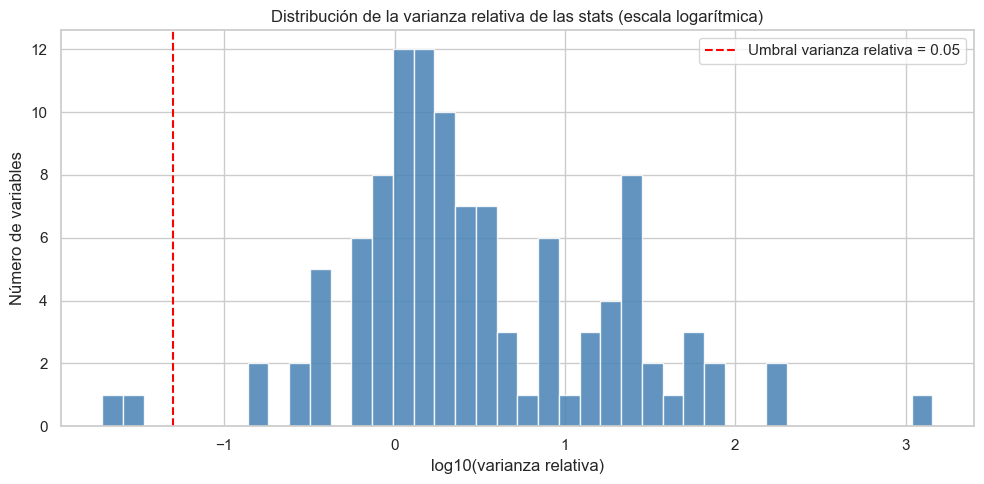

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log10(var_rel + 1e-10), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('log10(varianza relativa)')
ax.set_ylabel('Número de variables')
ax.set_title('Distribución de la varianza relativa de las stats (escala logarítmica)')
ax.axvline(np.log10(0.05), color='red', linestyle='--', label='Umbral varianza relativa = 0.05')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** las variables con varianza relativa muy baja (`rating`, `accuratePassesPercentage`)
son métricas que se concentran en un rango estrecho — todos los jugadores profesionales tienen un
rating entre 6 y 8, y un porcentaje de pase preciso entre 70% y 90%. **No carecen de valor
discriminativo**, pero su contribución a un modelo necesita estar bien escalada.

**Decisión:** **no eliminar** ninguna variable por baja varianza en esta fase. La decisión final se
hará en feature engineering tras evaluar su correlación con el target.

## 4. Matriz de correlación

Se calcula la matriz de correlación de Pearson entre las 110 variables. Esto permite detectar
**pares altamente redundantes**, que aportan información casi idéntica al modelo y deberían reducirse.

Matriz de correlación: (110, 110)


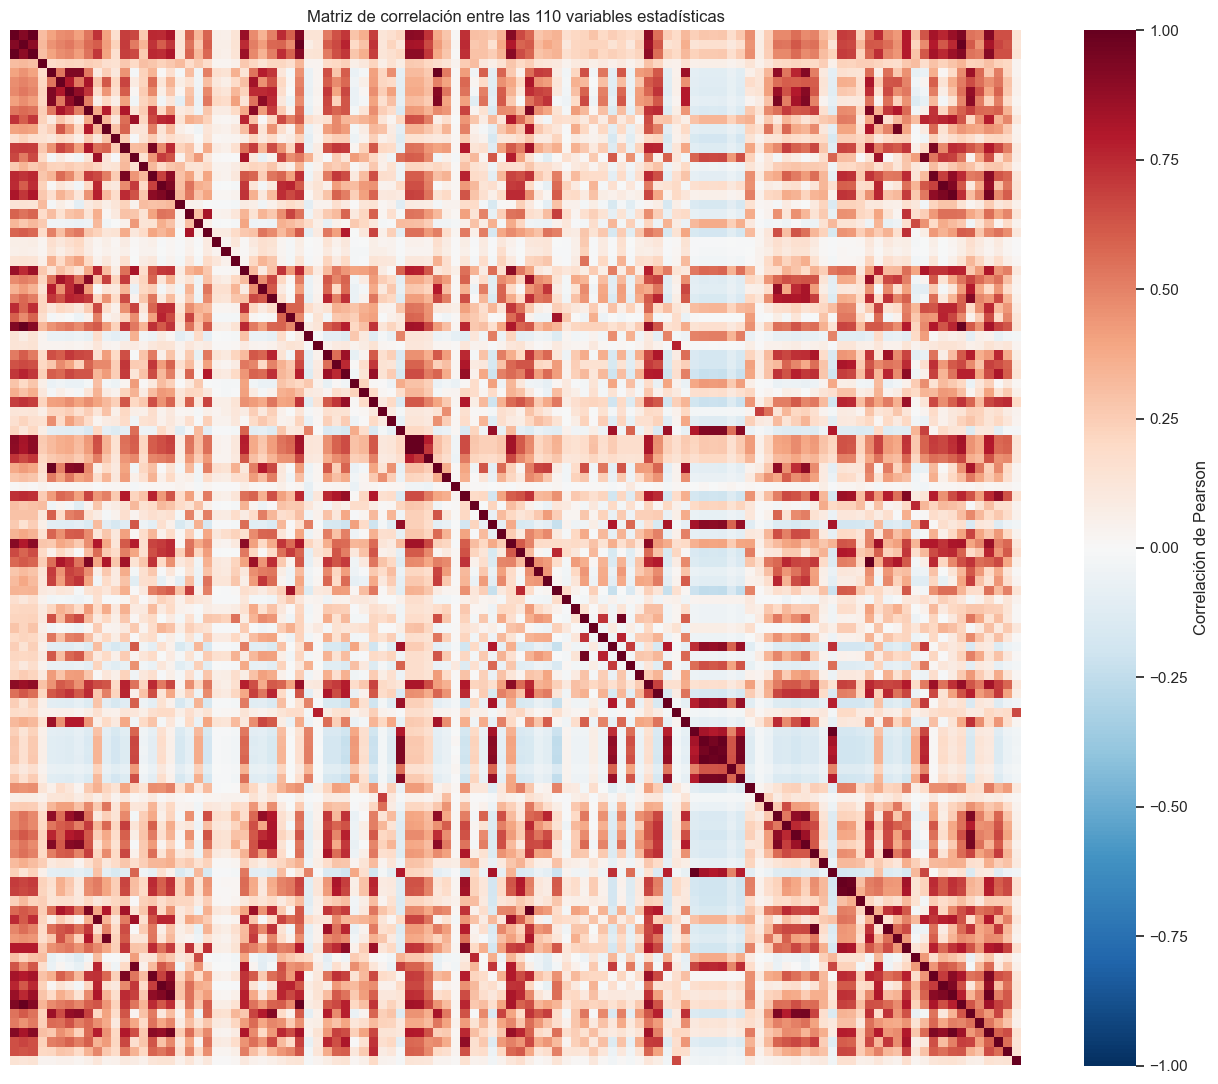

In [5]:
# Matriz de correlación (sobre filas con datos no nulos en al menos un par)
corr = X.corr()
print(f'Matriz de correlación: {corr.shape}')

# Heatmap general
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Correlación de Pearson'}, ax=ax)
ax.set_title('Matriz de correlación entre las 110 variables estadísticas')
plt.tight_layout()
plt.show()

**Lectura del heatmap:** las "manchas rojas" intensas que se ven fuera de la diagonal son **bloques
de variables altamente correlacionadas**. Visualmente se intuyen 5-7 grupos temáticos
(stats ofensivas, defensivas, de pase, de portero, etc.).

A continuación se cuantifica esta redundancia.

### 4.1 Pares altamente correlacionados

In [6]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_pairs = corr.abs().where(mask).stack().sort_values(ascending=False)

# Recuento de pares por umbral
umbrales = [0.99, 0.95, 0.90, 0.80, 0.70, 0.50]
print('=== Pares de variables por umbral de correlación absoluta ===')
for u in umbrales:
    n = (corr_pairs >= u).sum()
    print(f'   |r| ≥ {u:.2f}: {n:>4} pares')

=== Pares de variables por umbral de correlación absoluta ===
   |r| ≥ 0.99:   10 pares
   |r| ≥ 0.95:   27 pares
   |r| ≥ 0.90:   67 pares
   |r| ≥ 0.80:  199 pares
   |r| ≥ 0.70:  454 pares
   |r| ≥ 0.50: 1206 pares


In [7]:
print('=== Top 20 pares más correlacionados ===')
display(corr_pairs.head(20).round(3).to_frame('|r|'))

=== Top 20 pares más correlacionados ===


|r|
keyPasses                    totalAttemptAssist         1.000
accurateOwnHalfPasses        totalOwnHalfPasses         0.999
runsOut                      successfulRunsOut          0.999
countRating                  totalRating                0.998
appearances                  countRating                0.997
                             totalRating                0.995
savedShotsFromInsideTheBox   saves                      0.995
minutesPlayed                matchesStarted             0.994
goalsConceded                goalsConcededInsideTheBox  0.994
accuratePasses               totalPasses                0.993
goals                        goalsFromInsideTheBox      0.985
savedShotsFromOutsideTheBox  saves                      0.983
tackles                      tacklesWon                 0.982
totalPasses                  touches                    0.979
accurateOppositionHalfPasses totalOppositionHalfPasses  0.978
accurateChippedPasses        totalChippedPasses         0.973
successfulDribbles           totalContest               0.970
penaltiesTaken               penaltyGoals               0.967
saves                        savesParried               0.966
accurateLongBalls            totalLongBalls             0.966

**Hallazgo:** existe una redundancia masiva. Encontramos pares con correlación prácticamente perfecta:

- `keyPasses` ↔ `totalAttemptAssist` (r ≈ 1.000): son métricamente la misma variable.
- `accurateOwnHalfPasses` ↔ `totalOwnHalfPasses` (r ≈ 0.999): el contador "preciso" y el "total" se
  comportan idénticamente porque la inmensa mayoría de los pases en campo propio son acertados.
- `runsOut` ↔ `successfulRunsOut` (r ≈ 0.998): mismo patrón.
- `appearances`, `countRating` y `totalRating` (r ≈ 0.997 entre cada par): variables proxy
  unas de otras.

**Implicación crítica para el modelo de similitud:** si dos jugadores tienen los mismos `keyPasses`,
también tendrán los mismos `totalAttemptAssist`. Mantener ambas en el cálculo de distancias es
**equivalente a darle peso doble a esa información**, distorsionando los rankings de similitud.
Es imprescindible eliminar redundancias antes de aplicar k-NN.

## 5. Clustering jerárquico de variables

Para identificar **grupos temáticos** de variables (en lugar de tratar cada par redundante por separado),
se aplica un **clustering jerárquico aglomerativo** sobre la matriz de distancias derivada de la correlación:

$$d(X_i, X_j) = 1 - |r_{ij}|$$

Variables que tienden a aparecer juntas (r alto) se agrupan en el mismo cluster.

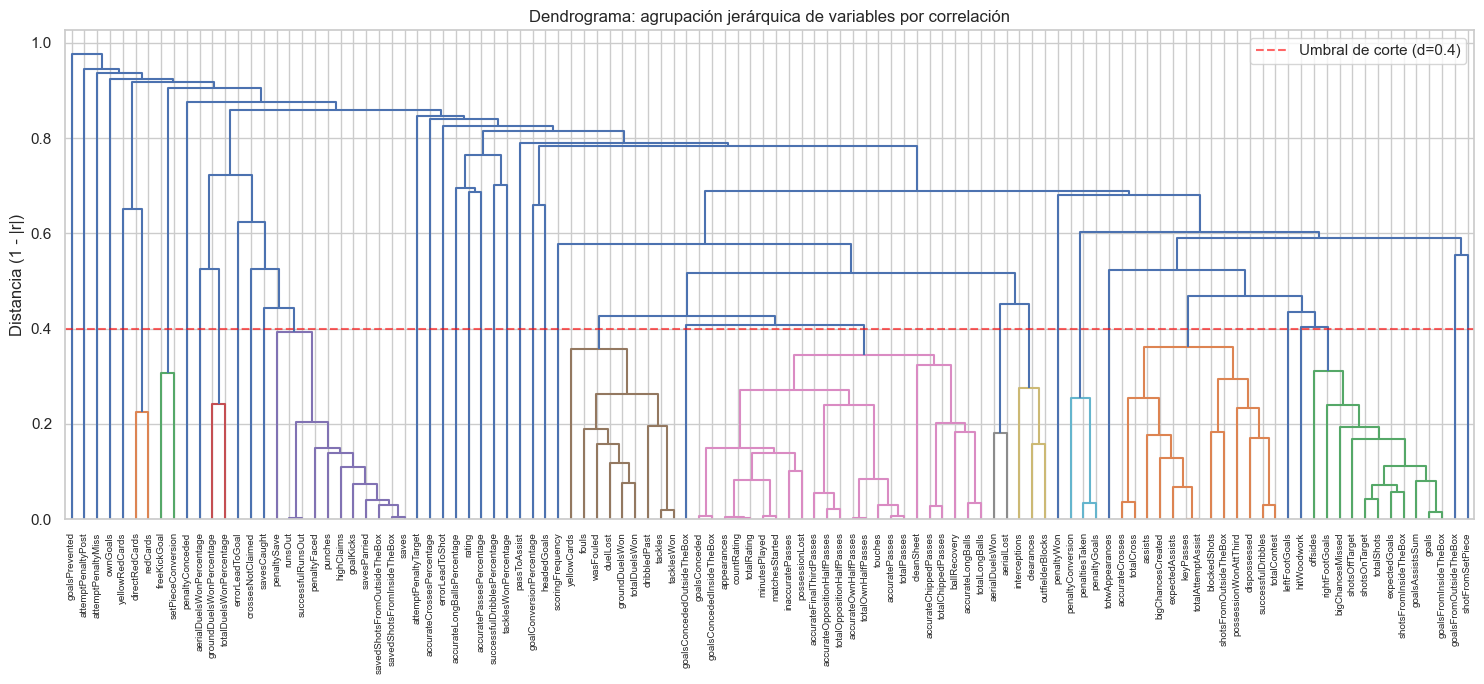

In [8]:
# Distancia: 1 - |corr|
dist_matrix = 1 - corr.abs()
np.fill_diagonal(dist_matrix.values, 0)

# Linkage para clustering jerárquico (método 'average' funciona bien con distancias de correlación)
condensed = squareform(dist_matrix.values, checks=False)
Z = linkage(condensed, method='average')

# Dendrograma
fig, ax = plt.subplots(figsize=(15, 7))
dendrogram(Z, labels=corr.columns.tolist(), leaf_rotation=90, leaf_font_size=7,
           color_threshold=0.4, ax=ax)
ax.axhline(0.4, color='red', linestyle='--', alpha=0.6, label='Umbral de corte (d=0.4)')
ax.set_ylabel('Distancia (1 - |r|)')
ax.set_title('Dendrograma: agrupación jerárquica de variables por correlación')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Asignar cluster a cada variable con corte en distancia 0.4 (es decir |r| ≥ 0.6 dentro del cluster)
clusters = fcluster(Z, t=0.4, criterion='distance')

cluster_df = pd.DataFrame({
    'variable': corr.columns,
    'cluster':  clusters
}).sort_values(['cluster','variable'])

n_clusters = cluster_df['cluster'].nunique()
print(f'Número de clusters identificados: {n_clusters}')
print(f'\n=== Tamaño de cada cluster ===')
print(cluster_df['cluster'].value_counts().sort_index().to_string())

Número de clusters identificados: 40

=== Tamaño de cada cluster ===
cluster
1      2
2      1
3      2
4      2
5      1
6     11
7      1
8      1
9      1
10     1
11     1
12     1
13     1
14     1
15     1
16     1
17     9
18    23
19     1
20     2
21     3
22     1
23     3
24    13
25    11
26     1
27     1
28     1
29     1
30     1
31     1
32     1
33     1
34     1
35     1
36     1
37     1
38     1
39     1
40     1


In [10]:
# Mostrar los clusters más grandes con sus variables
print('=== Composición de los clusters más grandes (top 8) ===\n')
for cl, grupo in cluster_df.groupby('cluster'):
    if len(grupo) >= 4:
        print(f'--- Cluster {cl} ({len(grupo)} variables) ---')
        for v in grupo['variable'].tolist():
            print(f'   {v}')
        print()

=== Composición de los clusters más grandes (top 8) ===

--- Cluster 6 (11 variables) ---
   goalKicks
   highClaims
   penaltyFaced
   penaltySave
   punches
   runsOut
   savedShotsFromInsideTheBox
   savedShotsFromOutsideTheBox
   saves
   savesParried
   successfulRunsOut

--- Cluster 17 (9 variables) ---
   dribbledPast
   duelLost
   fouls
   groundDuelsWon
   tackles
   tacklesWon
   totalDuelsWon
   wasFouled
   yellowCards

--- Cluster 18 (23 variables) ---
   accurateChippedPasses
   accurateFinalThirdPasses
   accurateLongBalls
   accurateOppositionHalfPasses
   accurateOwnHalfPasses
   accuratePasses
   appearances
   ballRecovery
   cleanSheet
   countRating
   goalsConceded
   goalsConcededInsideTheBox
   inaccuratePasses
   matchesStarted
   minutesPlayed
   possessionLost
   totalChippedPasses
   totalLongBalls
   totalOppositionHalfPasses
   totalOwnHalfPasses
   totalPasses
   totalRating
   touches

--- Cluster 24 (13 variables) ---
   accurateCrosses
   assists
   b

**Interpretación e identificación temática de los clusters:**

El clustering jerárquico, basado únicamente en correlaciones numéricas y sin ningún conocimiento previo
del fútbol, ha **redescubierto las facetas naturales del juego**:

| Cluster | Nº vars | Etiqueta interpretada | Variables características |
|---|---:|---|---|
| **18** | 23 | **Volumen / Pase posicional** | `minutesPlayed`, `appearances`, `totalPasses`, `accuratePasses`, `touches`, `ballRecovery`... |
| **24** | 13 | **Creación ofensiva** | `keyPasses`, `expectedAssists`, `assists`, `bigChancesCreated`, `totalCross`, `successfulDribbles`... |
| **25** | 11 | **Definición / Finalización** | `goals`, `expectedGoals`, `totalShots`, `shotsOnTarget`, `bigChancesMissed`... |
| **6** | 11 | **Portería** | `saves`, `savesParried`, `savedShotsFromInsideTheBox`, `goalKicks`, `highClaims`, `penaltySave`... |
| **17** | 9 | **Duelos / Defensa de contacto** | `tackles`, `tacklesWon`, `duelLost`, `fouls`, `wasFouled`, `yellowCards`, `dribbledPast`... |

Estos cinco clusters grandes acumulan **67 variables** (61% del total), mientras que las 43 variables
restantes se dispersan en 35 clusters pequeños (1-3 variables). Este patrón refleja la realidad del
dataset: un núcleo de variables temáticamente coherentes y una cola de métricas muy específicas
(p. ej. `goalsPrevented`, `freeKickGoal`, `penaltyMiss`) que el clustering aísla por su naturaleza
particular.

**Detalle interesante:** `goalsPrevented` (xG concedido − goles concedidos) aparece **separado del
cluster de Portería** a pesar de aplicar solo a porteros. Esto se debe a que es una **métrica derivada**
con un comportamiento numérico distinto al de los contadores brutos de paradas: puede ser negativa,
mide eficacia y no volumen.

**Decisión para el FE:** seleccionar **una variable representativa por cluster temático**, o aplicar
PCA dentro de cada bloque por separado para conservar señal sin redundancia.

## 6. Análisis de Componentes Principales (PCA)

¿Cuál es la **dimensión intrínseca** del dataset? Si tenemos 110 variables pero muchas están
correlacionadas, probablemente la información "real" se concentre en muchos menos ejes.

El PCA descompone la matriz de datos estandarizada en componentes ortogonales ordenados por la
varianza que explican. La **curva de varianza acumulada** indica cuántos componentes hace falta
mantener para conservar un porcentaje dado de la información original.

### 6.1 Preparación: imputación y estandarización

El PCA requiere una matriz sin nulos y con variables estandarizadas (media 0, desviación 1) para que
ninguna variable domine por su unidad de medida. Para esta fase exploratoria:
- **Imputamos los nulos restantes con la mediana** de cada columna (es una decisión solo para el PCA
  exploratorio; el tratamiento definitivo se hace en FE).
- **Estandarizamos** con `StandardScaler`.

In [11]:
# Imputación con mediana
X_imp = X.fillna(X.median(numeric_only=True))

# Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(X_imp)

print(f'Matriz para PCA: {X_std.shape}')
print(f'Nulos restantes: {np.isnan(X_std).sum()}')

Matriz para PCA: (20307, 110)
Nulos restantes: 0


### 6.2 Curva de varianza explicada

In [12]:
pca = PCA()
pca.fit(X_std)

var_exp     = pca.explained_variance_ratio_
var_acum    = np.cumsum(var_exp)
n_compon    = len(var_exp)

# Componentes necesarios para alcanzar 80%, 90%, 95%
n_80 = np.argmax(var_acum >= 0.80) + 1
n_90 = np.argmax(var_acum >= 0.90) + 1
n_95 = np.argmax(var_acum >= 0.95) + 1

print(f'Total de componentes:               {n_compon}')
print(f'Componentes para 80% de varianza:   {n_80}  ({n_80/n_compon*100:.1f}% del total)')
print(f'Componentes para 90% de varianza:   {n_90}  ({n_90/n_compon*100:.1f}% del total)')
print(f'Componentes para 95% de varianza:   {n_95}  ({n_95/n_compon*100:.1f}% del total)')

Total de componentes:               110
Componentes para 80% de varianza:   22  (20.0% del total)
Componentes para 90% de varianza:   37  (33.6% del total)
Componentes para 95% de varianza:   49  (44.5% del total)


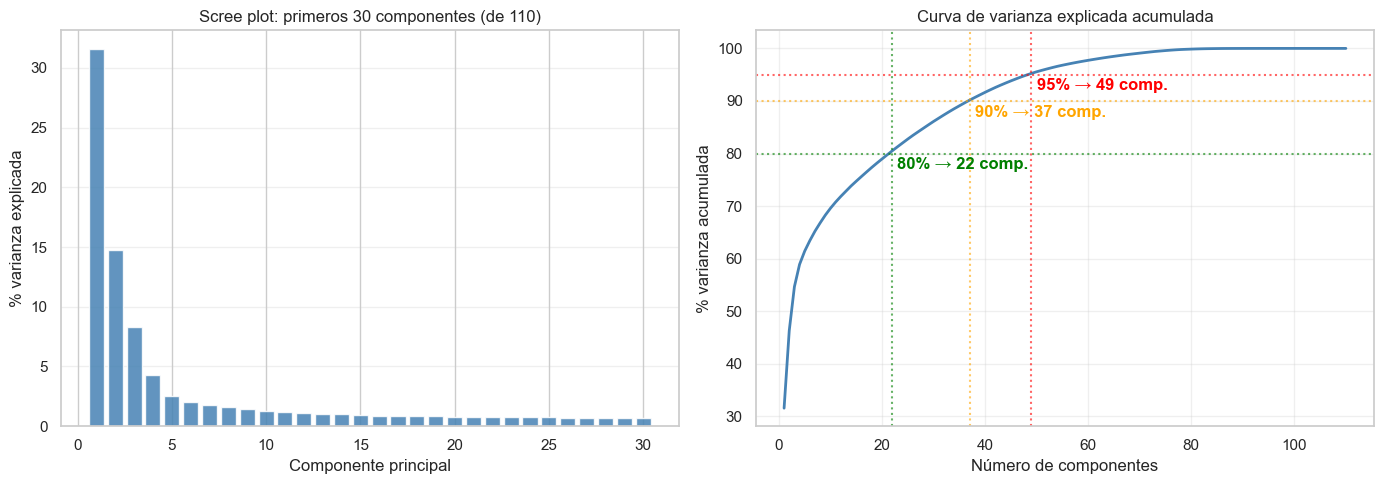

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (varianza por componente)
ax = axes[0]
ax.bar(range(1, min(n_compon, 30)+1), var_exp[:30]*100, color='steelblue', alpha=0.85)
ax.set_xlabel('Componente principal')
ax.set_ylabel('% varianza explicada')
ax.set_title(f'Scree plot: primeros 30 componentes (de {n_compon})')
ax.grid(axis='y', alpha=0.3)

# Curva acumulada
ax = axes[1]
ax.plot(range(1, n_compon+1), var_acum*100, marker='', lw=2, color='steelblue')
for thr, n_thr, color in [(80, n_80, 'green'), (90, n_90, 'orange'), (95, n_95, 'red')]:
    ax.axhline(thr, color=color, linestyle=':', alpha=0.6)
    ax.axvline(n_thr, color=color, linestyle=':', alpha=0.6)
    ax.text(n_thr+1, thr-3, f'{thr}% → {n_thr} comp.', color=color, fontweight='bold')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('% varianza acumulada')
ax.set_title('Curva de varianza explicada acumulada')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Hallazgo central del PCA:** la dimensión intrínseca del dataset es mucho menor que las 110
variables originales. Con un número moderado de componentes se captura la mayor parte de la varianza,
lo que confirma cuantitativamente la fuerte redundancia detectada en la matriz de correlación.

### Implicaciones

**Para el modelo de regresión salarial:**
- No es estrictamente necesario reducir dimensionalidad si se usan modelos robustos a multicolinealidad
  (Random Forest, Gradient Boosting). Pero sí conviene si se opta por modelos lineales (Ridge, Lasso).
- Lasso resolvería automáticamente la selección.

**Para el modelo de similitud:**
- **Reducir dimensionalidad es muy recomendable**. Trabajar con 110 features altamente correlacionadas
  hace que las distancias estén dominadas por bloques temáticos sobrerrepresentados.
- Una opción es trabajar directamente en el espacio PCA con los componentes que capturan el 80-90%.
- Otra opción es seleccionar una variable representativa por cluster del dendrograma.

## 7. Resumen y decisiones para feature engineering

### Hallazgos principales

| Aspecto | Resultado |
|---|---|
| **Volumen de variables** | 110 stats numéricas en el dataset |
| **Variables casi constantes** | Ninguna a eliminar a priori; varianza relativa baja en métricas porcentuales (esperado) |
| **Redundancia** | 27 pares con r ≥ 0.95, 67 pares con r ≥ 0.90, 199 pares con r ≥ 0.80 |
| **Estructura temática** | Variables agrupables en ~5-7 clusters mediante clustering jerárquico |
| **Dimensión intrínseca** | Mucho menor que 110: bastan unos pocos componentes para capturar el grueso de la varianza |

### Decisiones que se trasladan a la fase 05

1. **Eliminar redundancias críticas** (r ≥ 0.95): pares como `keyPasses`/`totalAttemptAssist` o
   `accurateOwnHalfPasses`/`totalOwnHalfPasses` deben colapsarse a una sola variable.

2. **Selección por cluster temático:** mantener una variable representativa por cada cluster del
   dendrograma, o aplicar PCA dentro de cada bloque temático.

3. **Estrategias diferenciadas según modelo:**
   - **Regresión salarial**: usar modelos robustos a multicolinealidad (XGBoost, Random Forest) o
     selección automática (Lasso). Con árboles, la redundancia no es un problema crítico.
   - **Similitud entre jugadores**: imprescindible reducir dimensionalidad (PCA o selección manual)
     antes del cálculo de distancias.

4. **Normalización per-90 minutos:** para variables que escalan con el tiempo de juego (goles,
   asistencias, pases, tiros), conviene transformarlas a tasa por 90 minutos para hacer comparables
   a jugadores con distinta exposición. Decisión que se concreta en el FE.

5. **Tratamiento separado de stats por posición:** los porteros deberían analizarse con sus
   variables específicas (`saves`, `goalsPrevented`...), y los jugadores de campo con las suyas.